# 04 — Trust Engine: Isolation Forest Training

**DESIGN.md §2C**: Train an unsupervised anomaly detection model to identify
spam and malicious crowd reports based on behavioural features.

This notebook:
1. Generates a synthetic dataset of 1,000 user reports
2. Injects 5% anomalous data simulating bot behaviour
3. Trains a `sklearn.ensemble.IsolationForest` on the combined data
4. Evaluates detection accuracy against ground-truth labels
5. Saves the fitted model to `models/trust_engine/isolation_forest.joblib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

## 1. Synthetic Data Generation

### Feature Definitions

| Feature | Description | Normal Range | Anomalous Range |
|---------|-------------|--------------|------------------|
| `user_account_age_days` | Days since account creation | 30 – 730 | 0 – 5 |
| `reports_last_24h` | Submission velocity | 0 – 3 | 15 – 50 |
| `rating_deviation` | Std. dev. of user's ratings from area baseline | 0.0 – 1.0 | 2.5 – 4.5 |

**Normal users** (95%): established accounts, low submission frequency, ratings close to baseline.  
**Anomalous users** (5%): new accounts, high-frequency submissions, ratings far from baseline.

In [2]:
N_TOTAL = 1000
ANOMALY_FRACTION = 0.05

n_normal = int(N_TOTAL * (1 - ANOMALY_FRACTION))
n_anomaly = N_TOTAL - n_normal

# Normal user reports
normal_data = np.column_stack([
    np.random.uniform(30, 730, size=n_normal),    # account_age_days
    np.random.poisson(1.0, size=n_normal),         # reports_last_24h
    np.abs(np.random.normal(0.3, 0.25, size=n_normal)),  # rating_deviation
])

# Anomalous user reports (bot-like behaviour)
anomaly_data = np.column_stack([
    np.random.uniform(0, 5, size=n_anomaly),       # very new accounts
    np.random.randint(15, 50, size=n_anomaly),      # high-frequency submissions
    np.random.uniform(2.5, 4.5, size=n_anomaly),    # extreme rating deviation
])

# Combine
X = np.vstack([normal_data, anomaly_data]).astype(np.float32)
ground_truth = np.array([1] * n_normal + [-1] * n_anomaly)  # 1=inlier, -1=outlier

# Shuffle
shuffle_idx = np.random.permutation(N_TOTAL)
X = X[shuffle_idx]
ground_truth = ground_truth[shuffle_idx]

FEATURE_NAMES = ['user_account_age_days', 'reports_last_24h', 'rating_deviation']
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['ground_truth'] = ground_truth
df['label'] = df['ground_truth'].map({1: 'Normal', -1: 'Anomaly'})

print(f'Total samples   : {N_TOTAL}')
print(f'Normal          : {n_normal} ({100*(1-ANOMALY_FRACTION):.0f}%)')
print(f'Anomalous       : {n_anomaly} ({100*ANOMALY_FRACTION:.0f}%)')
print()
df.describe().round(3)

Total samples   : 1000
Normal          : 950 (95%)
Anomalous       : 50 (5%)



,user_account_age_days,reports_last_24h,rating_deviation,ground_truth
count,1000.000,1000.000,1000.000,1000.000
mean,355.563,2.619,0.483,0.900
std,216.011,7.330,0.732,0.436
min,0.068,0.000,0.000,-1.000
25%,158.125,0.000,0.159,1.000
50%,354.232,1.000,0.322,1.000
75%,542.934,2.000,0.506,1.000
max,729.802,49.000,4.489,1.000


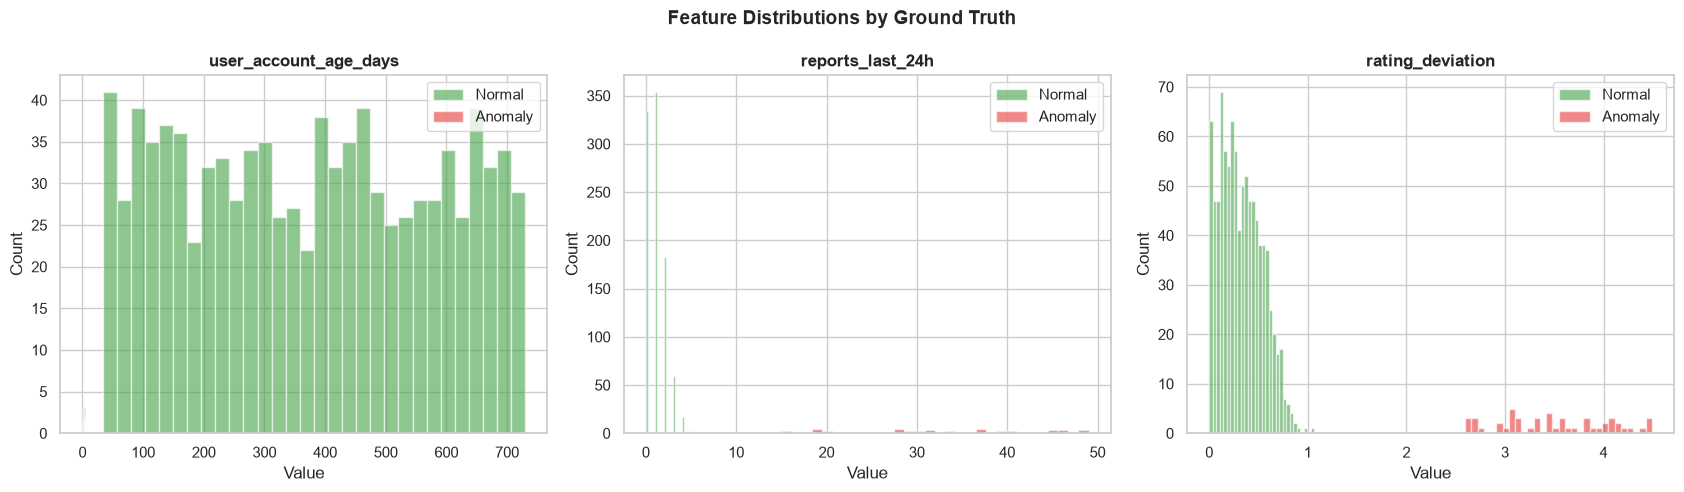

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col in zip(axes, FEATURE_NAMES):
    for label, color in [('Normal', '#43A047'), ('Anomaly', '#E53935')]:
        subset = df[df['label'] == label]
        ax.hist(subset[col], bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions by Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train the Isolation Forest

The model is trained unsupervised (no labels). We set `contamination=0.05`
to match the known anomaly fraction in the synthetic data.

In [4]:
model = IsolationForest(
    n_estimators=100,
    contamination=ANOMALY_FRACTION,
    random_state=42,
    n_jobs=-1,
)

model.fit(X)

predictions = model.predict(X)
anomaly_scores = model.decision_function(X)

df['prediction'] = predictions
df['pred_label'] = df['prediction'].map({1: 'Normal', -1: 'Anomaly'})
df['anomaly_score'] = anomaly_scores

print(f'Predicted Normal  : {(predictions == 1).sum()}')
print(f'Predicted Anomaly : {(predictions == -1).sum()}')

Predicted Normal  : 950
Predicted Anomaly : 50


## 3. Evaluation

              precision    recall  f1-score   support

Anomaly (-1)      1.000     1.000     1.000        50
  Normal (1)      1.000     1.000     1.000       950

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000



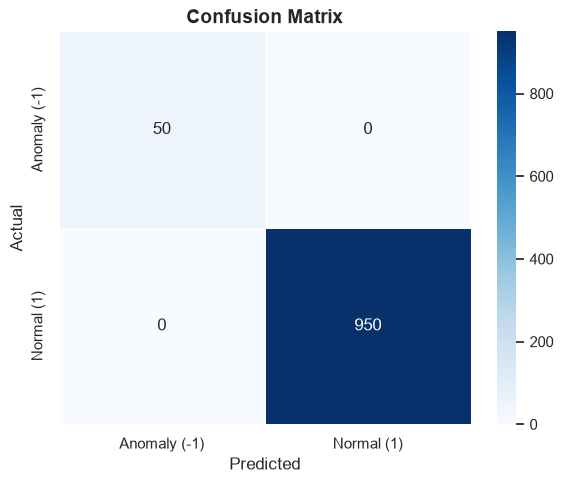

In [5]:
target_names = ['Anomaly (-1)', 'Normal (1)']
print(classification_report(
    ground_truth, predictions,
    target_names=target_names,
    digits=3,
))

cm = confusion_matrix(ground_truth, predictions, labels=[-1, 1])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    ax=ax, linewidths=0.5,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

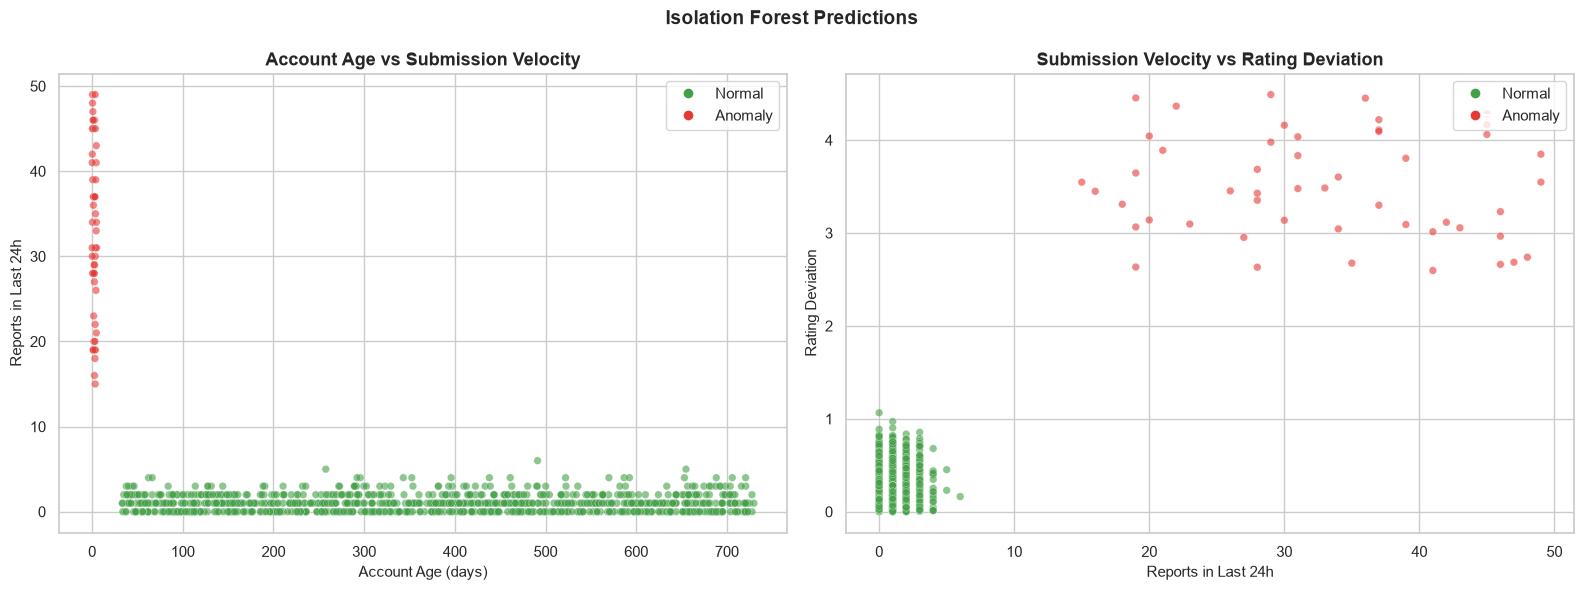

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: account_age vs reports_last_24h, coloured by prediction
colors = df['pred_label'].map({'Normal': '#43A047', 'Anomaly': '#E53935'})
axes[0].scatter(
    df['user_account_age_days'], df['reports_last_24h'],
    c=colors, alpha=0.6, edgecolors='white', linewidths=0.3, s=30,
)
axes[0].set_xlabel('Account Age (days)', fontsize=11)
axes[0].set_ylabel('Reports in Last 24h', fontsize=11)
axes[0].set_title('Account Age vs Submission Velocity', fontsize=13, fontweight='bold')

# Scatter: reports_last_24h vs rating_deviation, coloured by prediction
axes[1].scatter(
    df['reports_last_24h'], df['rating_deviation'],
    c=colors, alpha=0.6, edgecolors='white', linewidths=0.3, s=30,
)
axes[1].set_xlabel('Reports in Last 24h', fontsize=11)
axes[1].set_ylabel('Rating Deviation', fontsize=11)
axes[1].set_title('Submission Velocity vs Rating Deviation', fontsize=13, fontweight='bold')

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#43A047', markersize=8, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=8, label='Anomaly'),
]
for ax in axes:
    ax.legend(handles=legend_elements, loc='upper right')

plt.suptitle('Isolation Forest Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

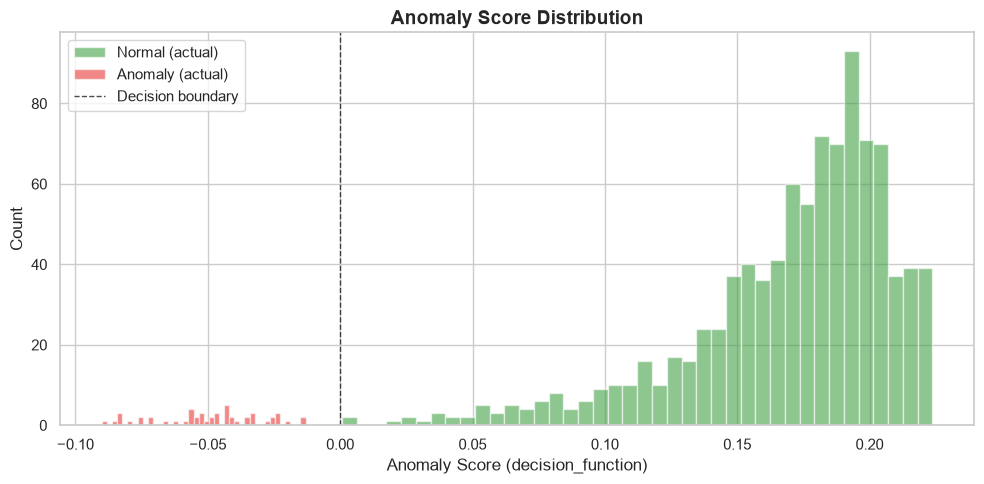

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color in [('Normal', '#43A047'), ('Anomaly', '#E53935')]:
    subset = df[df['label'] == label]
    ax.hist(subset['anomaly_score'], bins=40, alpha=0.6, color=color, label=f'{label} (actual)', edgecolor='white')

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Decision boundary')
ax.set_xlabel('Anomaly Score (decision_function)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Anomaly Score Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Save the Trained Model

In [8]:
MODEL_PATH = '../models/trust_engine/isolation_forest.joblib'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(model, MODEL_PATH)

print(f'Model saved to {MODEL_PATH}')

Model saved to ../models/trust_engine/isolation_forest.joblib


## 5. Verify: Load and Test

Reload the saved model and run a quick sanity check against
known normal and anomalous feature vectors.

In [9]:
loaded_model = joblib.load(MODEL_PATH)

# Test case: established user, low frequency, stable ratings
normal_sample = np.array([[200.0, 1.0, 0.2]])
# Test case: brand-new account, flooding reports, extreme deviation
anomaly_sample = np.array([[1.0, 30.0, 3.5]])

print('Verification results:')
print(f'  Normal sample  : prediction={loaded_model.predict(normal_sample)[0]:+d}  (expected +1)')
print(f'  Anomaly sample : prediction={loaded_model.predict(anomaly_sample)[0]:+d}  (expected -1)')

Verification results:
  Normal sample  : prediction=+1  (expected +1)
  Anomaly sample : prediction=-1  (expected -1)


In [10]:
print('=' * 60)
print('  TRUST ENGINE TRAINING COMPLETE')
print('=' * 60)
print(f'  Training samples  : {N_TOTAL}')
print(f'  Anomaly fraction  : {ANOMALY_FRACTION:.0%}')
print(f'  Features          : {FEATURE_NAMES}')
print(f'  Model             : IsolationForest(n_estimators=100)')
print(f'  Saved to          : {MODEL_PATH}')
print('=' * 60)

  TRUST ENGINE TRAINING COMPLETE
  Training samples  : 1000
  Anomaly fraction  : 5%
  Features          : ['user_account_age_days', 'reports_last_24h', 'rating_deviation']
  Model             : IsolationForest(n_estimators=100)
  Saved to          : ../models/trust_engine/isolation_forest.joblib
